## Optimizing progress variables for combustion using encoding-decoding networks

## 1) Setup

In [45]:
%run -i imports.py
%matplotlib inline
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
fm.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/Arial.ttf')
fm.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/arialbd.ttf')
plt.rcParams['font.family'] = 'Arial'
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

Python==3.10.13

numpy==1.26.2
pandas==2.1.3
scipy==1.11.4
scikit-learn==1.3.2
PCAfold==2.2.0


<Figure size 640x480 with 0 Axes>

In [46]:
### Parameters selection
data_type = 'FPF'
data_tag = 'M2'
target_variables_indices = [0, 5, 6, 7, 8, 9, 10, 13, 14, 15, 17, 20, 23, 24, 25, 26]

pure_streams = True #DO NOT modify it, unless you want to perform a "non-trainable pure streams analysis" (Refer to Section 3.4. The impact of training data preprocessing of https://doi.org/10.1016/j.combustflame.2025.114152)
%run -i ../scripts/fpf-load-data.py


Using: T, H2, H, O, OH, H2O, O2, NH3, NH2, NO2, NH, NO, N2O, CO2, CO, CH4 as target state variables at the decoder output.

9303 observations
56 state variables


## 2) Specify the cost function's hyper-parameters

In [47]:
power = 4
vertical_shift = 1
penalty_function = 'log-sigma-over-peak'

## 3) Parameterization with the optimized PV

In [48]:
### Random seed selection 
random_seeds_list = [0]
# random_seeds_list = [i for i in range(0,1)]

In [49]:
import pickle
costs_L2_RN = []

### Use your .pkl file
for random_seed in random_seeds_list:
    variance_data = pickle.load(open('../scripts/f-PV-tps-FPF-M2E4-target-T-H2-H-O-OH-H2O-O2-NH3-NH2-NO2-NH-NO-N2O-CO2-CO-CH4-RandomNormal-e-300000-CD-300000-lr-0.01-alr-0.001-scale-none-darch-0-10-10-rho-0.9-mom-0.5-momcent-no-VD-for-PV-source-rs-' + str(random_seed) + '.pkl', 'rb'))
    costs = analysis.cost_function_normalized_variance_derivative(variance_data,
                                                                  penalty_function=penalty_function,
                                                                  norm=None,
                                                                  power=power,
                                                                  vertical_shift=vertical_shift,
                                                                  integrate_to_peak=False)
     
    costs_L2_RN.append(np.linalg.norm(costs)/len(costs))

# Print the cost for each trained model/seed
print("Cost(s) of the random seed(s) which was/were analysed:", costs_L2_RN)

Cost(s) of the random seed(s) which was/were analysed: [0.27218685576263]


In [50]:
# Identifies which seed has the lowest cost
idx_optimized_basis, = np.where(costs_L2_RN==np.min(costs_L2_RN))
### Use your own best-model-weight.h5 file
# Load the weights of the best model
model_weights_filename = '../scripts/f-PV-tps-FPF-M2-target-T-H2-H-O-OH-H2O-O2-NH3-NH2-NO2-NH-NO-N2O-CO2-CO-CH4-RandomNormal-e-300000-CD-300000-lr-0.01-alr-0.001-scale-none-darch-0-10-10-rho-0.9-mom-0.5-momcent-no-best-model-weights-rs-' + str(idx_optimized_basis[0]) + '.h5'

In [51]:
hf = h5py.File(model_weights_filename, 'r')
optimized_basis = np.array(hf.get('0'))
hf.close()

In [52]:
# Construct the optimized PV
PV_optimized = np.dot(state_space[:,5::], optimized_basis)
PV_optimized_source = np.dot(state_space_sources[:,1::], optimized_basis)
T = state_space[:,0]


In [53]:
optimized_basis_normalized = (
    (optimized_basis - np.min(optimized_basis))
    / (np.max(optimized_basis) - np.min(optimized_basis))
)
# Flatten optimized_basis
optimized_basis_normalized_flat = np.asarray(optimized_basis_normalized).ravel()
# Create table

table_optimized_basis_normalized = pd.DataFrame({
    'w_i': optimized_basis_normalized_flat
})

# Round to 3 decimal places
table_optimized_basis_normalized['w_i'] = table_optimized_basis_normalized['w_i'].round(3)

print(table_optimized_basis_normalized)

# Save to CSV
table_optimized_basis_normalized.to_csv(
    'optimized_basis_normalized.csv',
    index=False,
    float_format='%.3f'
)



      w_i
0   0.068
1   0.482
2   0.460
3   0.584
4   0.642
5   0.457
6   0.520
7   1.000
8   0.391
9   0.427
10  0.543
11  0.504
12  0.439
13  0.454
14  0.494
15  0.338
16  0.502
17  0.500
18  0.477
19  0.890
20  0.647
21  0.388
22  0.411
23  0.562
24  0.513
25  0.486
26  0.489
27  0.576
28  0.492
29  0.536
30  0.500
31  0.534
32  0.500
33  0.537
34  0.498
35  0.500
36  0.491
37  0.000
38  0.496
39  0.491
40  0.500
41  0.487
42  0.501
43  0.500
44  0.500
45  0.500
46  0.506
47  0.503
48  0.503
49  0.501
50  0.777
    optimized_basis
0            -1.923
1            -0.081
2            -0.176
3             0.375
4             0.635
5            -0.191
6             0.088
7             2.229
8            -0.485
9            -0.326
10            0.192
11            0.018
12           -0.272
13           -0.206
14           -0.027
15           -0.722
16            0.009
17           -0.001
18           -0.100
19            1.738
20            0.656
21           -0.501
22           -0.396


In [54]:
### Use your .pkl file
# Calculate the cost specifically for the selected optimized seed
VarianceData_optimized = pickle.load(open('../scripts/f-PV-tps-FPF-M2E4-target-T-H2-H-O-OH-H2O-O2-NH3-NH2-NO2-NH-NO-N2O-CO2-CO-CH4-RandomNormal-e-300000-CD-300000-lr-0.01-alr-0.001-scale-none-darch-0-10-10-rho-0.9-mom-0.5-momcent-no-VD-for-PV-source-rs-' + str(idx_optimized_basis[0]) + '.pkl', 'rb'))

In [55]:
sigmas_optimized = VarianceData_optimized.bandwidth_values
D_hat_optimized = analysis.normalized_variance_derivative(VarianceData_optimized)

In [56]:
costs_optimized = analysis.cost_function_normalized_variance_derivative(VarianceData_optimized,
                                                              penalty_function=penalty_function,
                                                              norm=None,
                                                              power=power,
                                                              vertical_shift=vertical_shift,
                                                              integrate_to_peak=False)

L2_norm_cost_optimized = np.linalg.norm(costs_optimized)/len(costs_optimized)
print("Cost of the best random seed:", L2_norm_cost_optimized)

Cost of the best random seed: 0.27218685576263


## 4) Visualize the $(f, \text{PV})$ manifolds

<Figure size 2500x1000 with 0 Axes>

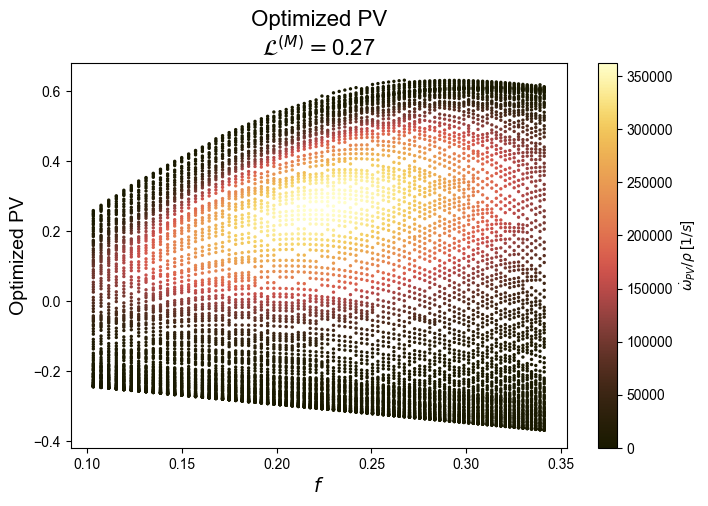

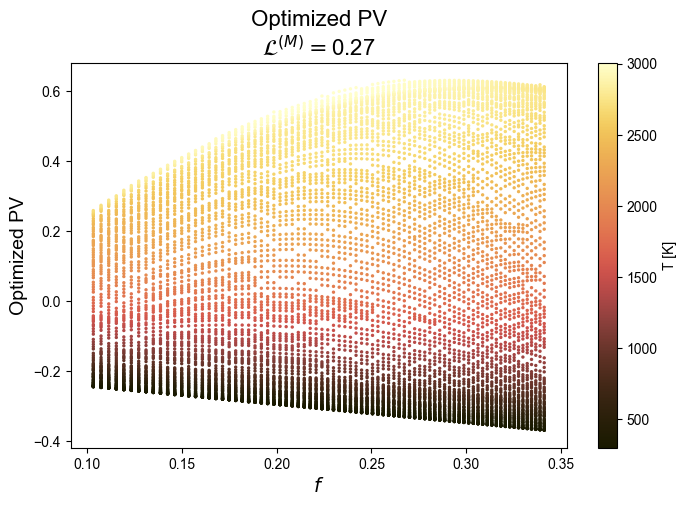

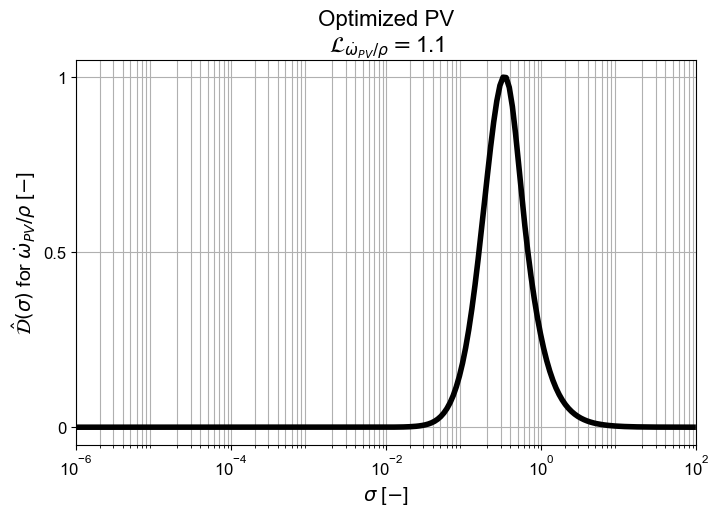

In [57]:
figure = plt.figure(figsize=(25, 10))
spec = figure.add_gridspec(ncols=7, nrows=3, width_ratios=[1,0,1,0,1,0,1], height_ratios=[1,0.2,0.9])

cmap = cmc.lajolla

fontsize = 20
fontsize_axes = 16
fontsize_subfigures = 26
s = 2

x_pos = -0.2
y_pos = 1.2

hfont = {'fontname':'Arial', 'fontweight':'bold'}

# # Manifolds - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
figure = plt.figure(figsize=(8,5))
figure_a = figure.add_subplot(111)
scat = plt.scatter(mf,PV_optimized,c=PV_optimized_source,s=2,cmap=cmc.lajolla,zorder=10)
plt.xlabel('$f$', fontsize=14)
plt.ylabel('Optimized PV', fontsize=14)
plt.title('Optimized PV\n'+ '$\mathcal{L}^{(M)}=$'+ str(round(L2_norm_cost_optimized,2)),fontsize=16)
cbar = plt.colorbar(scat)
cbar.set_label('$\dot{\omega}_{PV}/\\rho$ [$1/s$]', rotation=90)
plt.show()




#####
figure = plt.figure(figsize=(8,5))
figure_a = figure.add_subplot(111)
scat = plt.scatter(mf, PV_optimized,c=T,s=2,cmap=cmc.lajolla,zorder=10)
plt.xlabel('$f$', fontsize=14)
plt.ylabel('Optimized PV', fontsize=14)
plt.title('Optimized PV\n'+ '$\mathcal{L}^{(M)}=$'+ str(round(L2_norm_cost_optimized,2)),fontsize=16)
cbar = plt.colorbar(scat)
cbar.set_label('T [K]',rotation=90)
plt.show()



#####
figure = plt.figure(figsize=(8,5))
plt.semilogx(sigmas_optimized[1:-1],D_hat_optimized[0]['PV-source'],lw=4,c='k')
plt.xticks([10**-6, 10**-4, 10**-2, 10**0, 10**2],fontsize=12)
plt.yticks([0,0.5,1],['0','0.5','1'],fontsize=12)
plt.xlim([10**-6,10**2])
plt.xlabel('$\sigma$ [$-$]', fontsize=14)
plt.ylabel('$\\hat{\\mathcal{D}}(\\sigma)$ for $\\dot{\\omega}_{PV}/\\rho$ [$-$]',fontsize=14)
plt.title('Optimized PV\n'+ '$\\mathcal{L}_{\\dot{\\omega}_{PV}/\\rho}=$'+ str(round(costs_optimized[-1],1)),fontsize=16)
plt.grid(True, which="both")
plt.show()


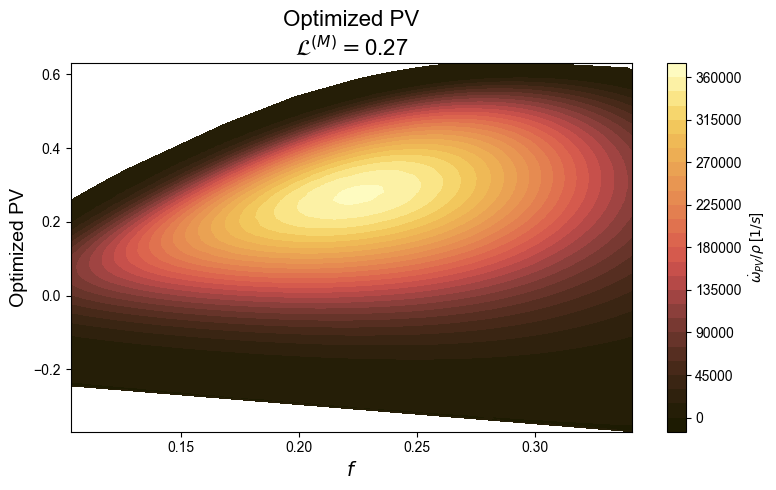

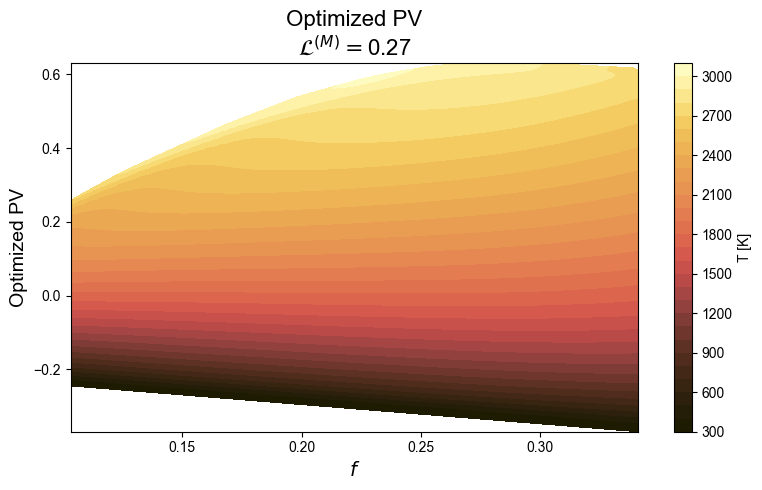

In [69]:
### Contour plot with color PV_ST
mf_1d = np.asarray(mf).ravel()
PV_optimized_1d = np.asarray(PV_optimized).ravel()
PV_optimized_source_1d = np.asarray(PV_optimized_source).ravel()

figure = plt.figure(figsize=(8, 5))
ax = figure.add_subplot(111)

contour = ax.tricontourf(mf_1d,PV_optimized_1d,PV_optimized_source_1d,levels=30,cmap=cmc.lajolla)
ax.set_xlabel('$f$', fontsize=14)
ax.set_ylabel('Optimized PV', fontsize=14)
ax.set_title('Optimized PV\n'+ '$\\mathcal{L}^{(M)}=$'+ str(round(L2_norm_cost_optimized, 2)),fontsize=16)

cbar = figure.colorbar(contour, ax=ax)
cbar.set_label('$\\dot{\\omega}_{PV}/\\rho$ [$1/s$]',rotation=90)

plt.tight_layout()
plt.show()

### Contour plot with color temperature
mf_1d = np.asarray(mf).ravel()
PV_optimized_1d = np.asarray(PV_optimized).ravel()
T_1d = np.asarray(T).ravel()

figure = plt.figure(figsize=(8, 5))
ax = figure.add_subplot(111)

contour = ax.tricontourf(mf_1d,PV_optimized_1d,T_1d,levels=30,cmap=cmc.lajolla)
ax.set_xlabel('$f$', fontsize=14)
ax.set_ylabel('Optimized PV', fontsize=14)
ax.set_title('Optimized PV\n'+ '$\\mathcal{L}^{(M)}=$'+ str(round(L2_norm_cost_optimized, 2)),fontsize=16)

cbar = figure.colorbar(contour, ax=ax)
cbar.set_label('T [K]',rotation=90)

plt.tight_layout()
plt.show()


## 5) Visualize the individual costs $\mathcal{L}_i$

In [59]:
### Modify names_neat according to the species of your mechanism
# names_neat = ['$T$', '$Y_{H}$', '$Y_{O_2}$', '$Y_{OH}$', '$Y_{O}$', '$Y_{H2}$', '$Y_{H_2O}$', '$Y_{CO}$', '$Y_{CO_2}$', '$\\frac{\dot{\omega}_{PV}}{\\rho}$']
# names_neat = ['$T$', '$Y_{H_2}$', '$Y_{H}$', '$Y_{O}$', '$Y_{OH}$', '$Y_{H_2O}$', '$Y_{O_2}$', '$Y_{H_2O_2}$', '$Y_{HO_2}$', '$Y_{NH_3}$', '$Y_{NH_2}$', '$Y_{NO_2}$', '$Y_{NH}$', '$Y_{NO}$', '$Y_{CO_2}$', '$Y_{CO}$', '$Y_{CH_4}$','$\\frac{\dot{\omega}_{PV}}{\\rho}$']
names_neat = [
    r'$T$',
    r'$\rho$',
    r'$\mu$',
    r'$\lambda$',
    r'$c_p$',
    r'$Y_{H_2}$',
    r'$Y_H$',
    r'$Y_O$',
    r'$Y_{OH}$',
    r'$Y_{H_2O}$',
    r'$Y_{NH_3}$',
    r'$Y_{NH_2}$',
    r'$Y_{NO_2}$',
    r'$Y_{NH}$',
    r'$Y_{NO}$',
    r'$Y_{N_2O}$',
    r'$Y_{CO_2}$',
    r'$Y_{CO}$',
    r'$Y_{CH_4}$',
    r'$\frac{\dot{\omega}_{PV}}{\rho}$'
]
print(len(costs_optimized))
print(len(names_neat))

20
20


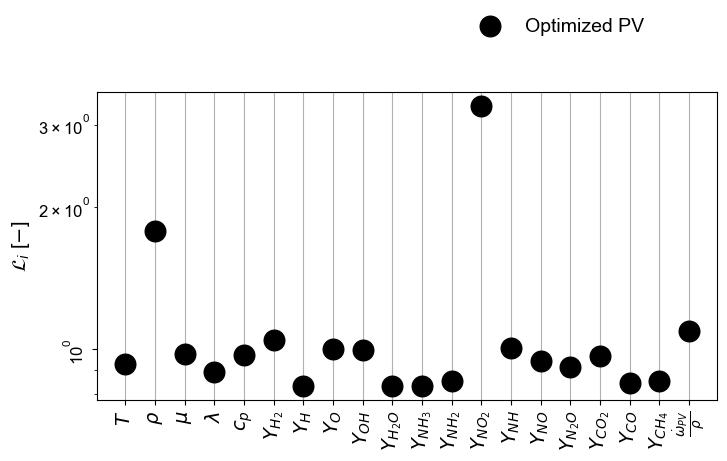

In [60]:
figure = plt.figure(figsize=(8, 4))
spec = figure.add_gridspec(ncols=1, nrows=1, width_ratios=[1], height_ratios=[1])

x_range = [i for i in range(0,len(names_neat))]
fontsize_axes = 12
fontsize = 14
s = 2

############################ Optimized PV ###########################
figure_a = figure.add_subplot(spec[0,0])
plt.scatter(x_range, costs_optimized, c='k', s=220, zorder=10, label='Optimized PV')
figure_a.xaxis.grid(True, alpha=1, zorder=1)
figure_a.tick_params(which='minor', labelsize=fontsize_axes)
figure_a.tick_params(which='major', rotation=90, labelsize=fontsize_axes)
plt.xticks(x_range, names_neat, fontsize=fontsize)
plt.ylabel('$\mathcal{L}_i$ [$-$]', fontsize=fontsize)
plt.yscale('log')
plt.legend(frameon=False, fontsize=fontsize, ncol=2, bbox_to_anchor=(0.91,1.3))

## 6) Comparison of the PV definitions

In [61]:
data_state_space = pd.read_csv("../data/FPF-"+data_tag+"-state-space.csv", header=None)
VD_target_variables_names = [
    'T',
    'rho',
    'mu',
    'lambda',
    'c_p',
    'H2',
    'H',
    'O',
    'OH', 
    'H2O', 
    'NH3', 
    'NH2', 
    'NO2', 
    'NH', 
    'NO', 
    'N2O', 
    'CO2', 
    'CO', 
    'CH4', 
    'PV_ST']
position_VD_target_variables = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 13, 14, 15, 17, 20, 23, 24, 25, 26]
VD_target_variables = data_state_space.iloc[:, position_VD_target_variables].to_numpy()
bandwidth_values = np.logspace(-6,2,200)

### Modify with your own PV definitions
VarianceData_PM = pickle.load(open('../comparison/VarianceData_'+ data_tag +'_PM.pkl', "rb")) #Pierce & Moin PV definition
VarianceData_IP = pickle.load(open('../comparison/VarianceData_' + data_tag + '_IP.pkl', "rb"))
VarianceData_F  = pickle.load(open('../comparison/VarianceData_' + data_tag + '_F.pkl', "rb"))
VarianceData_W  = pickle.load(open('../comparison/VarianceData_' + data_tag + '_W.pkl', "rb"))
VarianceData_M1 = pickle.load(open('../comparison/VarianceData_' + data_tag + '_M1.pkl', "rb"))
VarianceData_M2 = pickle.load(open('../comparison/VarianceData_' + data_tag + '_M2.pkl', "rb"))
VarianceData_X  = pickle.load(open('../comparison/VarianceData_' + data_tag + '_X.pkl', "rb"))
VarianceData_K1 = pickle.load(open('../comparison/VarianceData_' + data_tag + '_K1.pkl', "rb"))
VarianceData_K2 = pickle.load(open('../comparison/VarianceData_' + data_tag + '_K2.pkl', "rb"))
VarianceData_B  = pickle.load(open('../comparison/VarianceData_' + data_tag + '_B.pkl', "rb"))
VarianceData_O  = pickle.load(open('../comparison/VarianceData_' + data_tag + '_O.pkl', "rb"))

Cost of Pierce & Moin: 0.3819638942912583
T 0.905517019776545
rho 1.9106041611436406
mu 0.9601922383872707
lambda 0.870156083889594
c_p 0.968634833050449
H2 1.2860491699718644
H 0.8634541357986857
O 0.99984592490272
OH 0.9978503852989761
H2O 0.8221646938038036
NH3 0.8404585317463917
NH2 0.8693664850176637
NO2 6.139241486272313
NH 1.1270295680235636
NO 1.1751580675576188
N2O 0.907434774439353
CO2 0.964264564420868
CO 0.8589984094094134
CH4 0.8486711674579194
PV_ST 1.0885603855447035


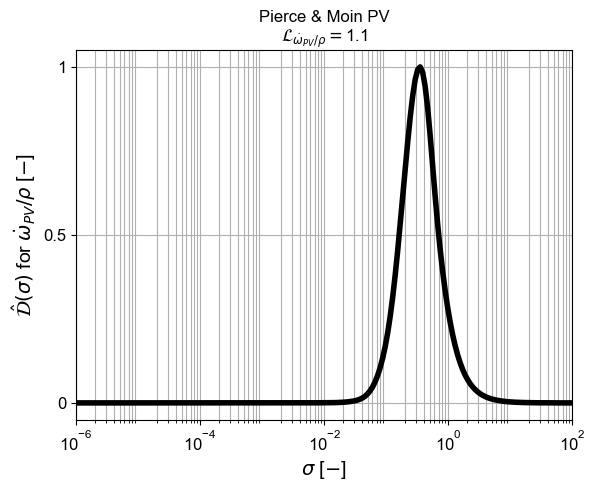

In [62]:
#Pierce & Moin PV definition
D_hat_PM = analysis.normalized_variance_derivative(VarianceData_PM)
sigmas_PM = VarianceData_PM.bandwidth_values

costs_PM = analysis.cost_function_normalized_variance_derivative(
    VarianceData_PM,
    penalty_function=penalty_function,
    norm=None,
    power=power,
    vertical_shift=vertical_shift,
    integrate_to_peak=False
)

L2_norm_cost_PM = np.linalg.norm(costs_PM) / len(costs_PM)

print("Cost of Pierce & Moin:", L2_norm_cost_PM)
for name, cost in zip(VD_target_variables_names, costs_PM):
    print(name, cost)


plt.figure()
plt.semilogx(sigmas_PM[1:-1], D_hat_PM[0]['PV_ST'], lw=4, c='k', zorder=10)
plt.xticks([10**-6, 10**-4, 10**-2, 10**0, 10**2], fontsize=fontsize_axes)
plt.yticks([0,0.5,1], ['0', '0.5', '1'], fontsize=fontsize_axes)
plt.xlim([10**-6,10**2])
plt.xlabel('$\sigma$ [$-$]', fontsize=14)
plt.ylabel('$\\hat{\\mathcal{D}}(\\sigma)$ for $\\dot{\\omega}_{PV}/\\rho$ [$-$]',fontsize=14)
plt.title('Pierce & Moin PV\n'+ '$\mathcal{L}_{\dot{\omega}_{PV} / \\rho} = $' + str(round(costs_PM[-1], 1)))
plt.grid(True, which="both")
plt.show()

Cost of Ihme & Pitsch: 2.4977785037507276
T 1.0013303424267188
rho 4.469199833537662
mu 1.1367967584219243
lambda 0.9237492122700375
c_p 0.9723974595522059
H2 2.2113838096085288
H 0.8786796412442553
O 1.0204769477084956
OH 1.081146364020607
H2O 0.8405676333431025
NH3 0.8277260421267126
NH2 0.9548490292032819
NO2 49.52368225232883
NH 1.3253258223754776
NO 1.2441050417661415
N2O 1.0596045710064315
CO2 1.1147662322392242
CO 0.8443198788947043
CH4 0.8472389462229806
PV_ST 1.2727460331546336


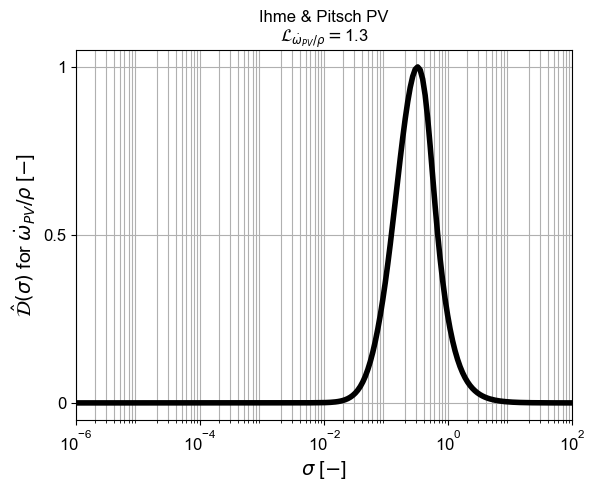

In [63]:
#Ihme & Pitsch PV definition
D_hat_IP = analysis.normalized_variance_derivative(VarianceData_IP)
sigmas_IP = VarianceData_IP.bandwidth_values


costs_IP = analysis.cost_function_normalized_variance_derivative(
    VarianceData_IP,
    penalty_function=penalty_function,
    norm=None,
    power=power,
    vertical_shift=vertical_shift,
    integrate_to_peak=False
)

L2_norm_cost_IP = np.linalg.norm(costs_IP) / len(costs_IP)

print("Cost of Ihme & Pitsch:", L2_norm_cost_IP)
for name, cost in zip(VD_target_variables_names, costs_IP):
    print(name, cost)



plt.figure()
plt.semilogx(sigmas_IP[1:-1], D_hat_IP[0]['PV_ST'], lw=4, c='k', zorder=10)
plt.xticks([10**-6, 10**-4, 10**-2, 10**0, 10**2], fontsize=fontsize_axes)
plt.yticks([0,0.5,1], ['0', '0.5', '1'], fontsize=fontsize_axes)
plt.xlim([10**-6,10**2])
plt.xlabel('$\sigma$ [$-$]', fontsize=14)
plt.ylabel('$\\hat{\\mathcal{D}}(\\sigma)$ for $\\dot{\\omega}_{PV}/\\rho$ [$-$]',fontsize=14)
plt.title('Ihme & Pitsch PV\n'+ '$\mathcal{L}_{\dot{\omega}_{PV} / \\rho} = $' + str(round(costs_IP[-1], 1)))
plt.grid(True, which="both")
plt.show()

Cost of Fiorina et al: 0.8997676007322639
T 1.0077781142826168
rho 3.348039891816377
mu 1.1166007659028032
lambda 0.9452790069788948
c_p 1.046182298906602
H2 1.7524745840894125
H 0.8708073204280325
O 1.0004191922449022
OH 1.0634973726054513
H2O 0.8588083491400871
NH3 0.8356741988127826
NH2 1.0010311563488623
NO2 17.07587727665028
NH 1.2441453340435957
NO 1.2644221414348034
N2O 1.0927002769081195
CO2 1.067211320251904
CO 0.8504027259435356
CH4 0.8597884573622148
PV_ST 1.2024783964864663


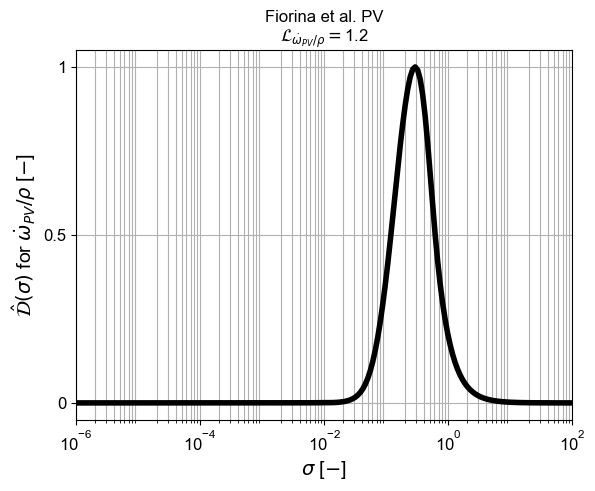

In [64]:
#Fiorina et al. PV definition
D_hat_F = analysis.normalized_variance_derivative(VarianceData_F)
sigmas_F = VarianceData_F.bandwidth_values


costs_F = analysis.cost_function_normalized_variance_derivative(
    VarianceData_F,
    penalty_function=penalty_function,
    norm=None,
    power=power,
    vertical_shift=vertical_shift,
    integrate_to_peak=False
)

L2_norm_cost_F = np.linalg.norm(costs_F) / len(costs_F)

print("Cost of Fiorina et al:", L2_norm_cost_F)
for name, cost in zip(VD_target_variables_names, costs_F):
    print(name, cost)


plt.figure()
plt.semilogx(sigmas_F[1:-1], D_hat_F[0]['PV_ST'], lw=4, c='k', zorder=10)
plt.xticks([10**-6, 10**-4, 10**-2, 10**0, 10**2], fontsize=fontsize_axes)
plt.yticks([0,0.5,1], ['0', '0.5', '1'], fontsize=fontsize_axes)
plt.xlim([10**-6,10**2])
plt.xlabel('$\sigma$ [$-$]', fontsize=14)
plt.ylabel('$\\hat{\\mathcal{D}}(\\sigma)$ for $\\dot{\\omega}_{PV}/\\rho$ [$-$]',fontsize=14)
plt.title('Fiorina et al. PV\n'+ '$\mathcal{L}_{\dot{\omega}_{PV} / \\rho} = $' + str(round(costs_F[-1], 1)))
plt.grid(True, which="both")
plt.show()

Cost of W: 0.3820145855929373
T 0.9051422449191189
rho 1.7996395712314825
mu 0.953425191394148
lambda 0.8628693778900361
c_p 0.9542679867285504
H2 1.2535049209676774
H 0.8826441850755832
O 1.0522375074986576
OH 1.0871251972333458
H2O 0.8231214132975911
NH3 0.8307309335982896
NH2 0.9350390546082549
NO2 5.96758007224861
NH 1.4251732943348547
NO 1.2479807194573183
N2O 1.039189915972635
CO2 1.162247184791138
CO 0.8627543092337908
CH4 0.8423725878042886
PV_ST 1.3361524032921783


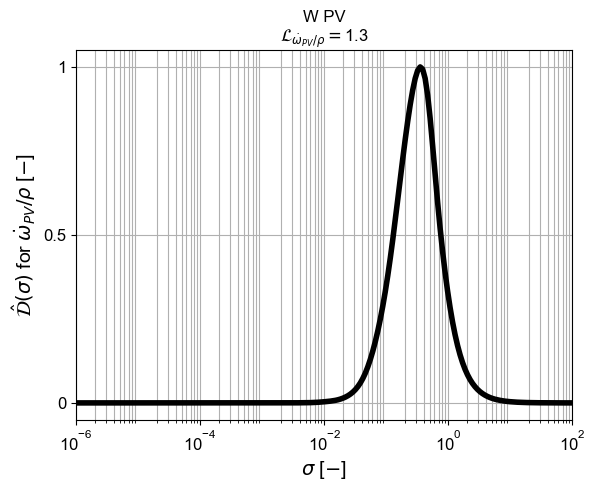

Cost of M1: 0.30271223373215095
T 0.9090899779512891
rho 1.649876486330951
mu 0.9465317655473766
lambda 0.8710519490307194
c_p 0.9491901878914908
H2 1.049824716724259
H 0.9245062225164636
O 1.0807177807732964
OH 1.0730564257025161
H2O 0.8161696543651309
NH3 0.8296557428083544
NH2 0.9053773790238151
NO2 3.72617979988171
NH 1.337783858304631
NO 1.603433323197368
N2O 1.0148831367781304
CO2 1.2389834478360968
CO 0.8650588449221833
CH4 0.8440297987376992
PV_ST 1.3522020454564065


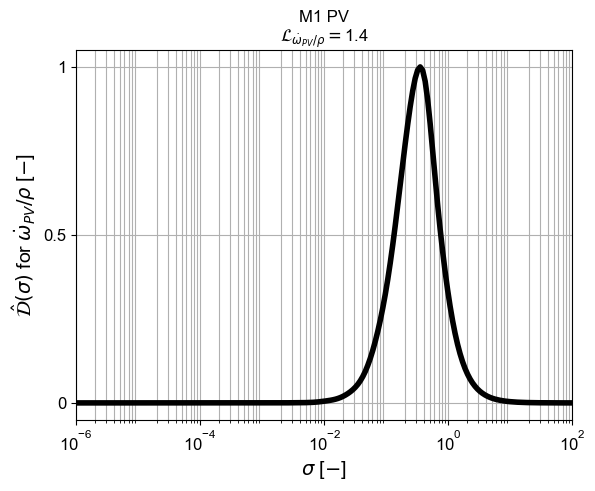

Cost of M2: 0.2836337754115294
T 0.9068550257501595
rho 1.634198460066358
mu 0.9528544110759004
lambda 0.8668083067220139
c_p 0.944380101600234
H2 1.042806938067645
H 0.8655476274719593
O 1.0505455776885002
OH 1.0699026453536449
H2O 0.8218911777172216
NH3 0.8214552199404955
NH2 0.906303500558277
NO2 3.433338000061978
NH 1.2574194495663495
NO 1.0129918311255115
N2O 1.0175398903928965
CO2 1.14405644800704
CO 0.8516850656028058
CH4 0.8353187833254224
PV_ST 1.3099751420772356


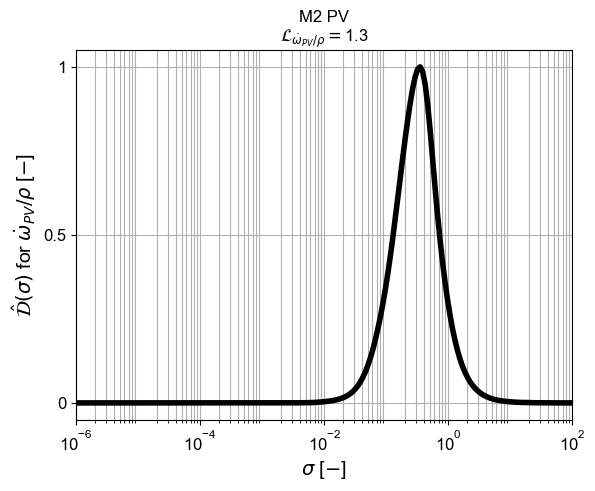

Cost of X: 0.27160441572829935
T 0.8935251714715815
rho 1.5123068336546164
mu 0.9310246372263941
lambda 0.8628161571815662
c_p 0.9478107522657733
H2 1.1220465870962824
H 0.8841802282420909
O 1.0648890607981836
OH 1.095735242514242
H2O 0.8212197953937346
NH3 0.8258627024020189
NH2 0.9449682478441787
NO2 2.8164404976954485
NH 1.453166598121808
NO 1.2549564811095921
N2O 1.0491281774563688
CO2 1.1748001886893147
CO 0.8605357372247981
CH4 0.8352607040916038
PV_ST 1.3227860848489337


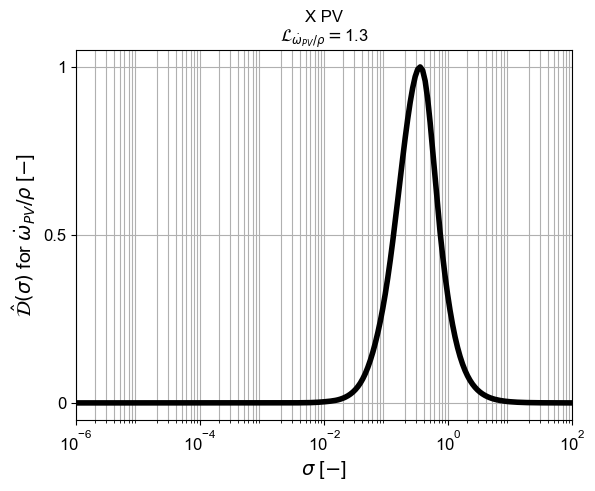

Cost of K1: 2.760094900524308
T 1.017696198644214
rho 4.669521544990397
mu 1.1611093976738258
lambda 0.9368883863338733
c_p 0.9706967426090158
H2 2.149200808982229
H 0.8975422778763087
O 1.034569410048275
OH 1.1082121753653849
H2O 0.8622688777017589
NH3 0.8351677038171049
NH2 0.9663810499620528
NO2 54.792218633940585
NH 1.3787509572611696
NO 1.0454756497065298
N2O 1.0875978710260115
CO2 1.2329705724395006
CO 0.8688584604296761
CH4 0.8544079698415132
PV_ST 1.3319123759963643


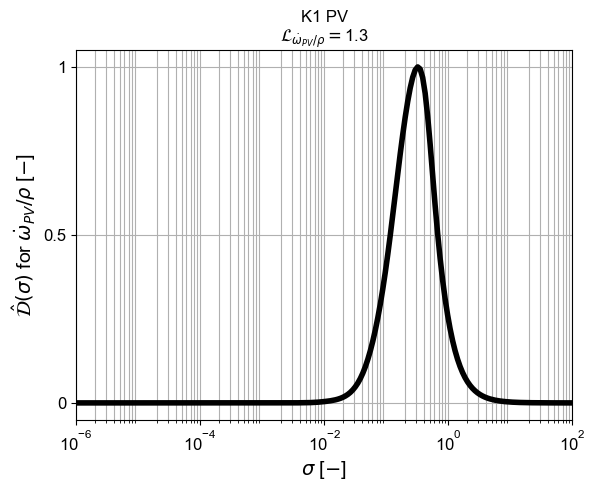

Cost of K2: 3.0182789448461724
T 0.9950427723154299
rho 4.688268355223182
mu 1.1430518183157818
lambda 0.9215082376374633
c_p 0.9597755789030386
H2 2.2117723772801368
H 0.8983389379514499
O 1.0407700783119442
OH 1.102087880488331
H2O 0.837662096749156
NH3 0.8271023793087775
NH2 0.963955315325494
NO2 59.98332423316928
NH 1.4535193809955629
NO 1.3001210265057712
N2O 1.075070513358533
CO2 1.201664678977763
CO 0.8613654129519372
CH4 0.8438040909348362
PV_ST 1.3373651788154648


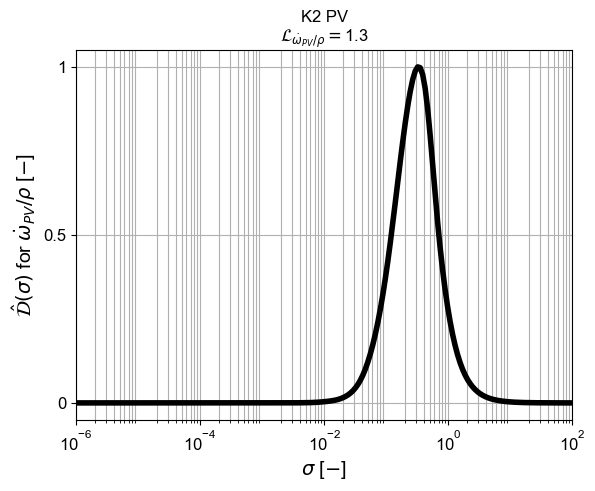

Cost of B: 0.4029469445907069
T 0.9172834386135338
rho 1.8722316125115375
mu 0.9665999178408253
lambda 0.869391973362157
c_p 0.9622964008363928
H2 1.2745819586714986
H 0.8916321557409878
O 1.0524284124620533
OH 1.0932858604688678
H2O 0.8257503562891219
NH3 0.8331072880508577
NH2 0.922759560054966
NO2 6.376542146414092
NH 1.358251541948329
NO 1.6726743596952474
N2O 1.0349816676960477
CO2 1.1867428613711168
CO 0.8616681549687479
CH4 0.8469911616131555
PV_ST 1.3384365288657178


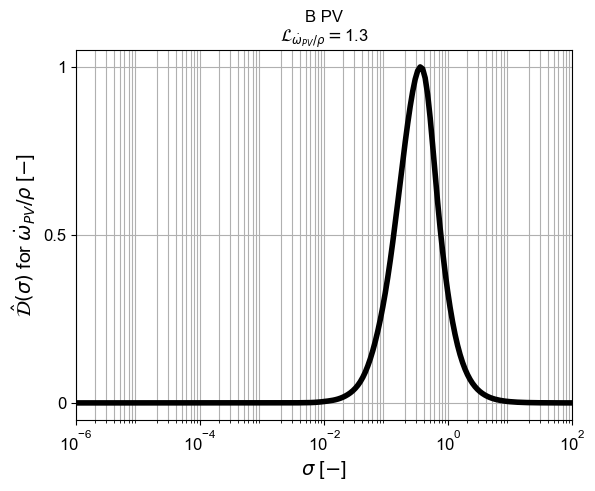

Cost of O: 1.7992656363119959
T 2.5829920522458862
rho 22.432322997962334
mu 3.33636752232229
lambda 2.4923795604330543
c_p 3.3229494474509105
H2 2.927274820041167
H 1.2221141649617817
O 1.1092808082087102
OH 1.1219728383377712
H2O 1.4376301708684125
NH3 1.1890158608061911
NH2 2.0391083038754125
NO2 26.788283683817177
NH 2.018662118747227
NO 1.7712688865256556
N2O 2.232183617669186
CO2 1.3592237759642005
CO 1.2307543526826528
CH4 1.2878325922029237
PV_ST 1.2877138982500251


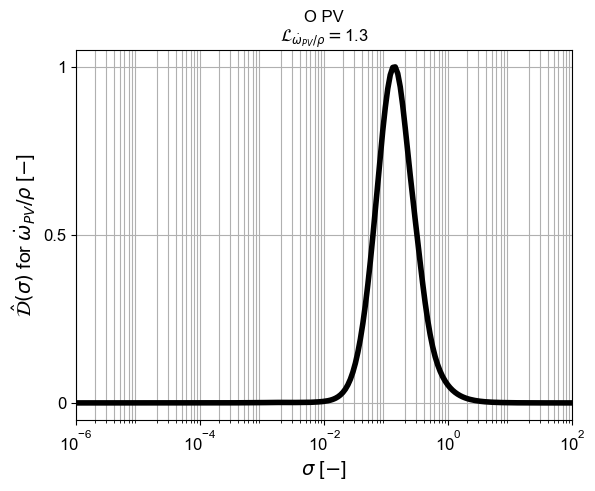

In [65]:
# W PV

D_hat_W = analysis.normalized_variance_derivative(VarianceData_W)
sigmas_W = VarianceData_W.bandwidth_values

costs_W = analysis.cost_function_normalized_variance_derivative(
    VarianceData_W,
    penalty_function=penalty_function,
    norm=None,
    power=power,
    vertical_shift=vertical_shift,
    integrate_to_peak=False
)

L2_norm_cost_W = np.linalg.norm(costs_W) / len(costs_W)

print("Cost of W:", L2_norm_cost_W)
for name, cost in zip(VD_target_variables_names, costs_W):
    print(name, cost)

plt.figure()
plt.semilogx(sigmas_W[1:-1], D_hat_W[0]['PV_ST'], lw=4, c='k', zorder=10)
plt.xticks([10**-6, 10**-4, 10**-2, 10**0, 10**2], fontsize=fontsize_axes)
plt.yticks([0, 0.5, 1], ['0', '0.5', '1'], fontsize=fontsize_axes)
plt.xlim([10**-6, 10**2])
plt.xlabel('$\sigma$ [$-$]', fontsize=14)
plt.ylabel('$\\hat{\\mathcal{D}}(\\sigma)$ for $\\dot{\\omega}_{PV}/\\rho$ [$-$]', fontsize=14)
plt.title('W PV\n' + '$\mathcal{L}_{\dot{\omega}_{PV} / \\rho} = $' + str(round(costs_W[-1], 1)))
plt.grid(True, which="both")
plt.show()


# M1 PV

D_hat_M1 = analysis.normalized_variance_derivative(VarianceData_M1)
sigmas_M1 = VarianceData_M1.bandwidth_values

costs_M1 = analysis.cost_function_normalized_variance_derivative(
    VarianceData_M1,
    penalty_function=penalty_function,
    norm=None,
    power=power,
    vertical_shift=vertical_shift,
    integrate_to_peak=False
)

L2_norm_cost_M1 = np.linalg.norm(costs_M1) / len(costs_M1)

print("Cost of M1:", L2_norm_cost_M1)
for name, cost in zip(VD_target_variables_names, costs_M1):
    print(name, cost)

plt.figure()
plt.semilogx(sigmas_M1[1:-1], D_hat_M1[0]['PV_ST'], lw=4, c='k', zorder=10)
plt.xticks([10**-6, 10**-4, 10**-2, 10**0, 10**2], fontsize=fontsize_axes)
plt.yticks([0, 0.5, 1], ['0', '0.5', '1'], fontsize=fontsize_axes)
plt.xlim([10**-6, 10**2])
plt.xlabel('$\sigma$ [$-$]', fontsize=14)
plt.ylabel('$\\hat{\\mathcal{D}}(\\sigma)$ for $\\dot{\\omega}_{PV}/\\rho$ [$-$]', fontsize=14)
plt.title('M1 PV\n' + '$\mathcal{L}_{\dot{\omega}_{PV} / \\rho} = $' + str(round(costs_M1[-1], 1)))
plt.grid(True, which="both")
plt.show()


# M2 PV

D_hat_M2 = analysis.normalized_variance_derivative(VarianceData_M2)
sigmas_M2 = VarianceData_M2.bandwidth_values

costs_M2 = analysis.cost_function_normalized_variance_derivative(
    VarianceData_M2,
    penalty_function=penalty_function,
    norm=None,
    power=power,
    vertical_shift=vertical_shift,
    integrate_to_peak=False
)

L2_norm_cost_M2 = np.linalg.norm(costs_M2) / len(costs_M2)

print("Cost of M2:", L2_norm_cost_M2)
for name, cost in zip(VD_target_variables_names, costs_M2):
    print(name, cost)

plt.figure()
plt.semilogx(sigmas_M2[1:-1], D_hat_M2[0]['PV_ST'], lw=4, c='k', zorder=10)
plt.xticks([10**-6, 10**-4, 10**-2, 10**0, 10**2], fontsize=fontsize_axes)
plt.yticks([0, 0.5, 1], ['0', '0.5', '1'], fontsize=fontsize_axes)
plt.xlim([10**-6, 10**2])
plt.xlabel('$\sigma$ [$-$]', fontsize=14)
plt.ylabel('$\\hat{\\mathcal{D}}(\\sigma)$ for $\\dot{\\omega}_{PV}/\\rho$ [$-$]', fontsize=14)
plt.title('M2 PV\n' + '$\mathcal{L}_{\dot{\omega}_{PV} / \\rho} = $' + str(round(costs_M2[-1], 1)))
plt.grid(True, which="both")
plt.show()


# X PV

D_hat_X = analysis.normalized_variance_derivative(VarianceData_X)
sigmas_X = VarianceData_X.bandwidth_values

costs_X = analysis.cost_function_normalized_variance_derivative(
    VarianceData_X,
    penalty_function=penalty_function,
    norm=None,
    power=power,
    vertical_shift=vertical_shift,
    integrate_to_peak=False
)

L2_norm_cost_X = np.linalg.norm(costs_X) / len(costs_X)

print("Cost of X:", L2_norm_cost_X)
for name, cost in zip(VD_target_variables_names, costs_X):
    print(name, cost)

plt.figure()
plt.semilogx(sigmas_X[1:-1], D_hat_X[0]['PV_ST'], lw=4, c='k', zorder=10)
plt.xticks([10**-6, 10**-4, 10**-2, 10**0, 10**2], fontsize=fontsize_axes)
plt.yticks([0, 0.5, 1], ['0', '0.5', '1'], fontsize=fontsize_axes)
plt.xlim([10**-6, 10**2])
plt.xlabel('$\sigma$ [$-$]', fontsize=14)
plt.ylabel('$\\hat{\\mathcal{D}}(\\sigma)$ for $\\dot{\\omega}_{PV}/\\rho$ [$-$]', fontsize=14)
plt.title('X PV\n' + '$\mathcal{L}_{\dot{\omega}_{PV} / \\rho} = $' + str(round(costs_X[-1], 1)))
plt.grid(True, which="both")
plt.show()


# K1 PV

D_hat_K1 = analysis.normalized_variance_derivative(VarianceData_K1)
sigmas_K1 = VarianceData_K1.bandwidth_values

costs_K1 = analysis.cost_function_normalized_variance_derivative(
    VarianceData_K1,
    penalty_function=penalty_function,
    norm=None,
    power=power,
    vertical_shift=vertical_shift,
    integrate_to_peak=False
)

L2_norm_cost_K1 = np.linalg.norm(costs_K1) / len(costs_K1)

print("Cost of K1:", L2_norm_cost_K1)
for name, cost in zip(VD_target_variables_names, costs_K1):
    print(name, cost)

plt.figure()
plt.semilogx(sigmas_K1[1:-1], D_hat_K1[0]['PV_ST'], lw=4, c='k', zorder=10)
plt.xticks([10**-6, 10**-4, 10**-2, 10**0, 10**2], fontsize=fontsize_axes)
plt.yticks([0, 0.5, 1], ['0', '0.5', '1'], fontsize=fontsize_axes)
plt.xlim([10**-6, 10**2])
plt.xlabel('$\sigma$ [$-$]', fontsize=14)
plt.ylabel('$\\hat{\\mathcal{D}}(\\sigma)$ for $\\dot{\\omega}_{PV}/\\rho$ [$-$]', fontsize=14)
plt.title('K1 PV\n' + '$\mathcal{L}_{\dot{\omega}_{PV} / \\rho} = $' + str(round(costs_K1[-1], 1)))
plt.grid(True, which="both")
plt.show()


# K2 PV

D_hat_K2 = analysis.normalized_variance_derivative(VarianceData_K2)
sigmas_K2 = VarianceData_K2.bandwidth_values

costs_K2 = analysis.cost_function_normalized_variance_derivative(
    VarianceData_K2,
    penalty_function=penalty_function,
    norm=None,
    power=power,
    vertical_shift=vertical_shift,
    integrate_to_peak=False
)

L2_norm_cost_K2 = np.linalg.norm(costs_K2) / len(costs_K2)

print("Cost of K2:", L2_norm_cost_K2)
for name, cost in zip(VD_target_variables_names, costs_K2):
    print(name, cost)

plt.figure()
plt.semilogx(sigmas_K2[1:-1], D_hat_K2[0]['PV_ST'], lw=4, c='k', zorder=10)
plt.xticks([10**-6, 10**-4, 10**-2, 10**0, 10**2], fontsize=fontsize_axes)
plt.yticks([0, 0.5, 1], ['0', '0.5', '1'], fontsize=fontsize_axes)
plt.xlim([10**-6, 10**2])
plt.xlabel('$\sigma$ [$-$]', fontsize=14)
plt.ylabel('$\\hat{\\mathcal{D}}(\\sigma)$ for $\\dot{\\omega}_{PV}/\\rho$ [$-$]', fontsize=14)
plt.title('K2 PV\n' + '$\mathcal{L}_{\dot{\omega}_{PV} / \\rho} = $' + str(round(costs_K2[-1], 1)))
plt.grid(True, which="both")
plt.show()


# B PV

D_hat_B = analysis.normalized_variance_derivative(VarianceData_B)
sigmas_B = VarianceData_B.bandwidth_values

costs_B = analysis.cost_function_normalized_variance_derivative(
    VarianceData_B,
    penalty_function=penalty_function,
    norm=None,
    power=power,
    vertical_shift=vertical_shift,
    integrate_to_peak=False
)

L2_norm_cost_B = np.linalg.norm(costs_B) / len(costs_B)

print("Cost of B:", L2_norm_cost_B)
for name, cost in zip(VD_target_variables_names, costs_B):
    print(name, cost)

plt.figure()
plt.semilogx(sigmas_B[1:-1], D_hat_B[0]['PV_ST'], lw=4, c='k', zorder=10)
plt.xticks([10**-6, 10**-4, 10**-2, 10**0, 10**2], fontsize=fontsize_axes)
plt.yticks([0, 0.5, 1], ['0', '0.5', '1'], fontsize=fontsize_axes)
plt.xlim([10**-6, 10**2])
plt.xlabel('$\sigma$ [$-$]', fontsize=14)
plt.ylabel('$\\hat{\\mathcal{D}}(\\sigma)$ for $\\dot{\\omega}_{PV}/\\rho$ [$-$]', fontsize=14)
plt.title('B PV\n' + '$\mathcal{L}_{\dot{\omega}_{PV} / \\rho} = $' + str(round(costs_B[-1], 1)))
plt.grid(True, which="both")
plt.show()


# O PV

D_hat_O = analysis.normalized_variance_derivative(VarianceData_O)
sigmas_O = VarianceData_O.bandwidth_values

costs_O = analysis.cost_function_normalized_variance_derivative(
    VarianceData_O,
    penalty_function=penalty_function,
    norm=None,
    power=power,
    vertical_shift=vertical_shift,
    integrate_to_peak=False
)

L2_norm_cost_O = np.linalg.norm(costs_O) / len(costs_O)

print("Cost of O:", L2_norm_cost_O)
for name, cost in zip(VD_target_variables_names, costs_O):
    print(name, cost)

plt.figure()
plt.semilogx(sigmas_O[1:-1], D_hat_O[0]['PV_ST'], lw=4, c='k', zorder=10)
plt.xticks([10**-6, 10**-4, 10**-2, 10**0, 10**2], fontsize=fontsize_axes)
plt.yticks([0, 0.5, 1], ['0', '0.5', '1'], fontsize=fontsize_axes)
plt.xlim([10**-6, 10**2])
plt.xlabel('$\sigma$ [$-$]', fontsize=14)
plt.ylabel('$\\hat{\\mathcal{D}}(\\sigma)$ for $\\dot{\\omega}_{PV}/\\rho$ [$-$]', fontsize=14)
plt.title('O PV\n' + '$\mathcal{L}_{\dot{\omega}_{PV} / \\rho} = $' + str(round(costs_O[-1], 1)))
plt.grid(True, which="both")
plt.show()

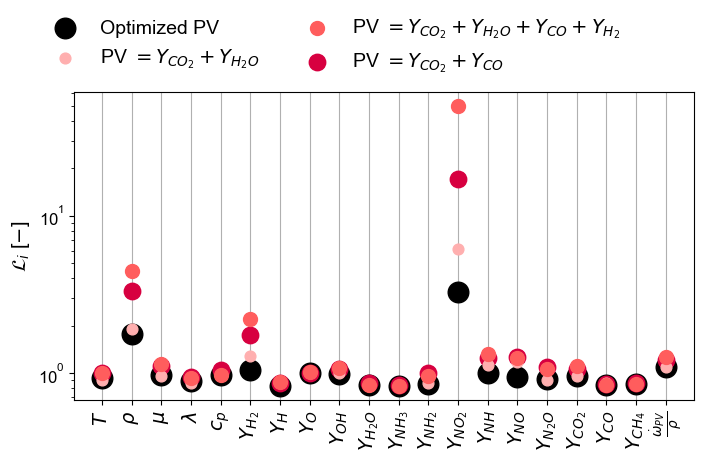

In [70]:
# Comparion of the individual costs between optimized PV and classical PV definitions (PM, IP, F)
figure = plt.figure(figsize=(8, 4))
spec = figure.add_gridspec(ncols=1, nrows=1, width_ratios=[1], height_ratios=[1])

x_range = [i for i in range(0,len(names_neat))]
fontsize_axes = 12
fontsize = 14
s = 2

figure_a = figure.add_subplot(spec[0,0])
plt.scatter(x_range, costs_optimized, c='k', s=220, zorder=10, label='Optimized PV')
plt.scatter(x_range, costs_PM, c='#ffafaf', s=60, zorder=30, label='PV $= Y_{CO_2} + Y_{H_2O} $')
plt.scatter(x_range, costs_IP, c='#ff5d5d', s=100, zorder=40, label='PV $ = Y_{CO_2} + Y_{H_2O} + Y_{CO} + Y_{H_2}$')
plt.scatter(x_range, costs_F, c='#d70040', s=140, zorder=20, label='PV $ = Y_{CO_2} + Y_{CO}$')
figure_a.xaxis.grid(True, alpha=1, zorder=1)
figure_a.tick_params(which='minor', labelsize=fontsize_axes)
figure_a.tick_params(which='major', labelsize=fontsize_axes)
plt.xticks(x_range, names_neat, rotation=90, fontsize=fontsize)
plt.ylabel('$\mathcal{L}_i$ [$-$]', fontsize=fontsize)
plt.yscale('log')
plt.legend(frameon=False, fontsize=fontsize, ncol=2, bbox_to_anchor=(0.91,1.3))

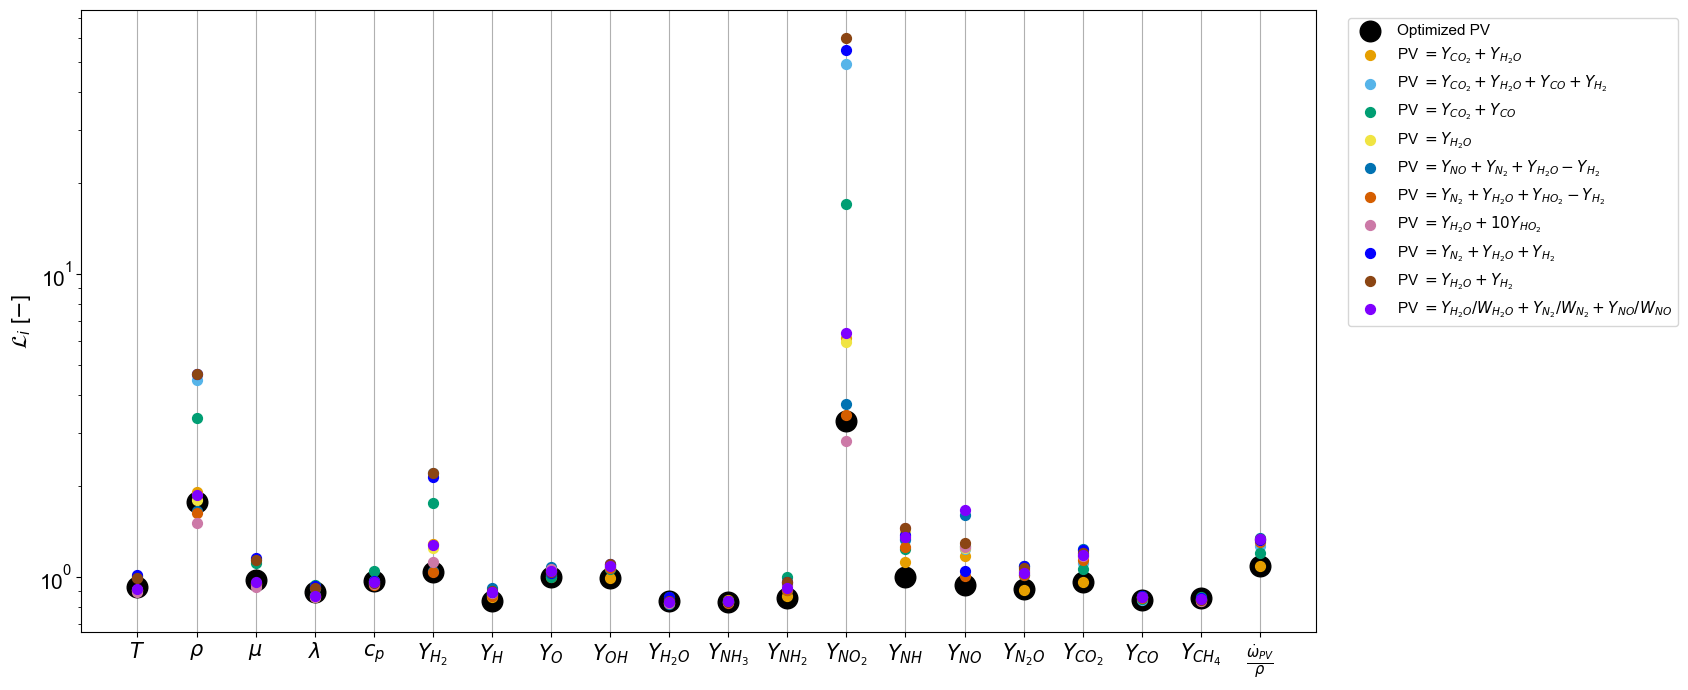

In [67]:
# Comparion of the individual costs between optimized PV and classical PV definitions (PM, IP, F, W, M1, M2, X, K1, K2, B, O)
figure = plt.figure(figsize=(17, 7))
spec = figure.add_gridspec(ncols=1, nrows=1, width_ratios=[1], height_ratios=[1])

x_range = [i for i in range(0,len(names_neat))]
fontsize_axes = 15
fontsize = 15
s = 2

figure_a = figure.add_subplot(spec[0,0])
plt.scatter(x_range, costs_optimized, c='k', s=220, zorder=10, label='Optimized PV')
plt.scatter(x_range, costs_PM, c="#E69F00", s=50, zorder=20, label='PV $= Y_{CO_2} + Y_{H_2O} $')
plt.scatter(x_range, costs_IP, c="#56B4E9", s=50, zorder=20, label='PV $ = Y_{CO_2} + Y_{H_2O} + Y_{CO} + Y_{H_2}$')
plt.scatter(x_range, costs_F, c="#009E73", s=50, zorder=20, label='PV $ = Y_{CO_2} + Y_{CO}$')
plt.scatter(x_range, costs_W, c="#F0E442", s=50, zorder=20,label='PV $ = Y_{H_2O}$')
plt.scatter(x_range, costs_M1, c="#0072B2", s=50, zorder=20,label='PV $ = Y_{NO} + Y_{N_2} + Y_{H_2O} - Y_{H_2}$')
plt.scatter(x_range, costs_M2, c="#D55E00", s=50, zorder=20,label='PV $ = Y_{N_2} + Y_{H_2O} + Y_{HO_2} - Y_{H_2}$')
plt.scatter(x_range, costs_X, c="#CC79A7", s=50, zorder=20,label='PV $ = Y_{H_2O} + 10Y_{HO_2}$')
plt.scatter(x_range, costs_K1, c="#0400FF", s=50, zorder=20,label='PV $ = Y_{N_2} + Y_{H_2O} + Y_{H_2}$')
plt.scatter(x_range, costs_K2, c="#8B4513", s=50, zorder=20,label='PV $ = Y_{H_2O} + Y_{H_2}$')
plt.scatter(x_range, costs_B, c="#7F00FF", s=50, zorder=20,label='PV $ = Y_{H_2O}/W_{H_2O} + Y_{N_2}/W_{N_2} + Y_{NO}/W_{NO}$')
# plt.scatter(x_range, costs_O, c="#FF1493", s=50, zorder=20,label='PV $ = Y_{CO_2}/W_{CO_2} + Y_{H_2O}/W_{H_2O} + Y_{H_2}/W_{H_2}$')

figure_a.xaxis.grid(True, alpha=1, zorder=1)
figure_a.tick_params(which='minor', labelsize=fontsize_axes)
figure_a.tick_params(which='major', labelsize=fontsize_axes)
plt.xticks(x_range, names_neat, fontsize=fontsize)
plt.ylabel('$\mathcal{L}_i$ [$-$]', fontsize=fontsize)
plt.yscale('log')
# plt.legend(frameon=False, fontsize=fontsize, ncol=2, bbox_to_anchor=(0.91,1.3))
plt.legend(loc='upper left',bbox_to_anchor=(1.02, 1),fontsize=11,frameon=True)

plt.tight_layout()
plt.savefig('figure.png', bbox_inches='tight', dpi=300)

In [68]:
PV_names = [
    'optimized', 
    'PM', 
    'IP', 
    'F', 
    'W', 
    'M1', 
    'M2',
    'X', 
    'K1', 
    'K2', 
    'B', 
    # 'O'
]

# Individual costs
costs_all = [
    costs_optimized,
    costs_PM,
    costs_IP,
    costs_F,
    costs_W,
    costs_M1,
    costs_M2,
    costs_X,
    costs_K1,
    costs_K2,
    costs_B
    # costs_O
]

# # Average/global costs
# average_costs = [
#     L2_norm_cost_optimized,
#     L2_norm_cost_PM,
#     L2_norm_cost_IP,
#     L2_norm_cost_F,
#     L2_norm_cost_W,
#     L2_norm_cost_M1,
#     L2_norm_cost_M2,
#     L2_norm_cost_X,
#     L2_norm_cost_K1,
#     L2_norm_cost_K2,
#     L2_norm_cost_B,
#     L2_norm_cost_O
# ]

# Create table with individual costs
table_individual_costs = pd.DataFrame(
    costs_all,
    index=PV_names,
    columns=VD_target_variables_names
)

# Put PV name in the first column
table_individual_costs.index.name = 'PV'
table_individual_costs = table_individual_costs.reset_index()

# Rename PV_ST
table_individual_costs = table_individual_costs.rename(
    columns={'PV_ST': 'PV source term'}
)

# Round numerical values
table_individual_costs.iloc[:, 1:] = (
    table_individual_costs.iloc[:, 1:].round(3)
)

print(table_individual_costs)


def save_cost_table_png(df, filename, fontsize=10):

    fig, ax = plt.subplots(figsize=(22, 6))
    ax.axis('off')

    # Create the table
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='center',
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.8)

    # Color scale for every numerical column
    for j, column in enumerate(df.columns):

        # Skip PV column
        if column == 'PV':
            continue

        values = df[column].astype(float).values

        # Normalize: low = 0, high = 1
        norm = mcolors.Normalize(
            vmin=np.min(values),
            vmax=np.max(values)
        )

        cmap = plt.cm.RdYlGn_r

        for i, value in enumerate(values):

            color = cmap(norm(value))

            # Table row is i+1 because row 0 is the header
            table[(i + 1, j)].set_facecolor(color)

    # Header formatting
    for j in range(len(df.columns)):
        table[(0, j)].set_facecolor('lightgray')
        table[(0, j)].set_text_props(weight='bold')

    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()


save_cost_table_png(
    table_individual_costs,
    'costs_comparison.png'
)
table_individual_costs.to_csv("FPF-"+ data_tag +"-costs-species.csv", index=False, header=True)

           PV      T    rho     mu  lambda    c_p     H2      H      O     OH  \
0   optimized  0.926  1.777  0.976   0.893  0.970  1.043  0.832  1.000  0.992   
1          PM  0.906  1.911  0.960   0.870  0.969  1.286  0.863  1.000  0.998   
2          IP  1.001  4.469  1.137   0.924  0.972  2.211  0.879  1.020  1.081   
3           F  1.008  3.348  1.117   0.945  1.046  1.752  0.871  1.000  1.063   
4           W  0.905  1.800  0.953   0.863  0.954  1.254  0.883  1.052  1.087   
5          M1  0.909  1.650  0.947   0.871  0.949  1.050  0.925  1.081  1.073   
6          M2  0.907  1.634  0.953   0.867  0.944  1.043  0.866  1.051  1.070   
7           X  0.894  1.512  0.931   0.863  0.948  1.122  0.884  1.065  1.096   
8          K1  1.018  4.670  1.161   0.937  0.971  2.149  0.898  1.035  1.108   
9          K2  0.995  4.688  1.143   0.922  0.960  2.212  0.898  1.041  1.102   
10          B  0.917  1.872  0.967   0.869  0.962  1.275  0.892  1.052  1.093   

    ...    NH3    NH2     N